In [1]:
import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

In [2]:
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')
xgb = joblib.load('fraud_xgb_model.pkl')

In [3]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

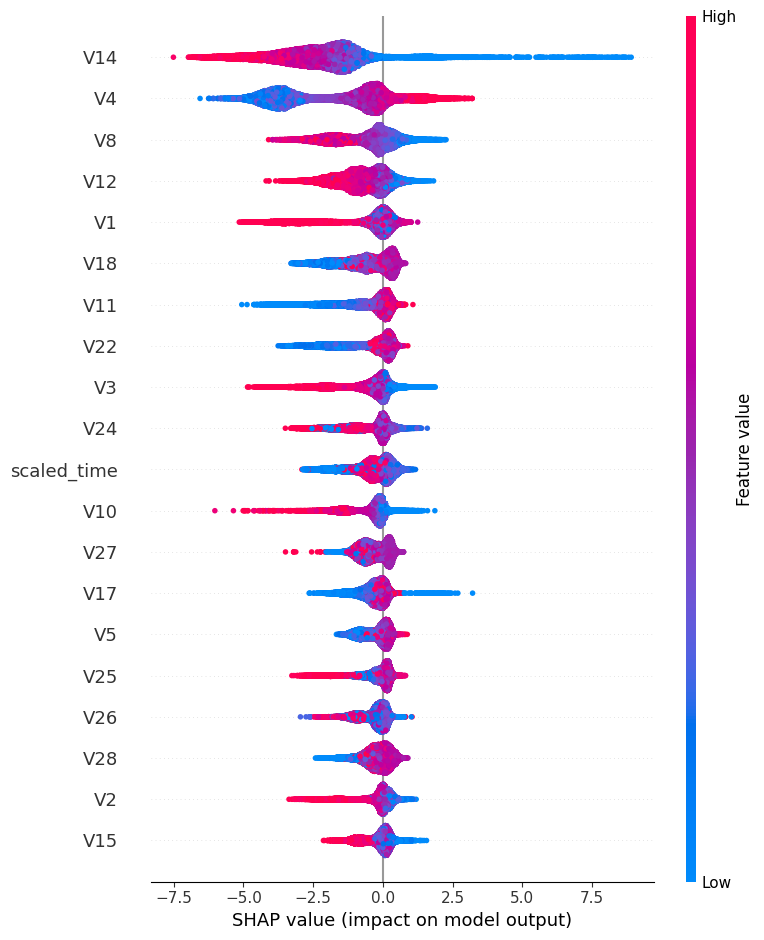

In [4]:
feature_names = [f'V{i}' for i in range(1, 29)] + ['scaled_amount', 'scaled_time']

shap.summary_plot(shap_values, X_test, feature_names=feature_names)

SHAP confirms V14 as the most influential feature, consistent with correlation analysis. However, V4 and V8 rank highly in SHAP despite weak linear correlation — revealing that XGBoost learned non-linear fraud patterns invisible to simple correlation. This demonstrates why model explainability tools like SHAP are essential beyond basic EDA.

In [5]:
import numpy as np

In [6]:
fraud_indices = np.where(y_test == 1)[0]
print(f"Total fraud cases in test set: {len(fraud_indices)}")

Total fraud cases in test set: 98


In [7]:
fraud_idx = fraud_indices[0]
print(f"Using transaction index: {fraud_idx}")

Using transaction index: 840


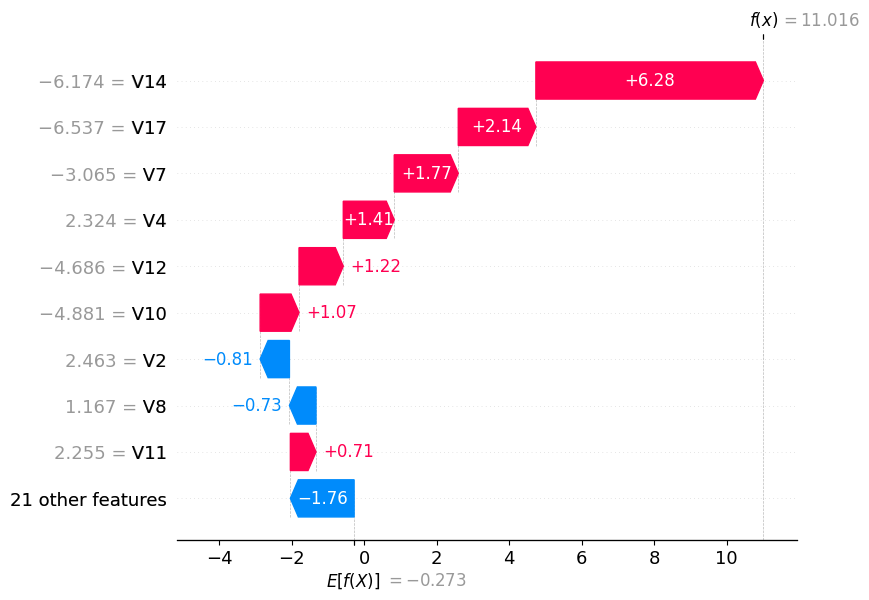

In [8]:
feature_names = [f'V{i}' for i in range(1, 29)] + ['scaled_amount', 'scaled_time']

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[fraud_idx],
        base_values=explainer.expected_value,
        data=X_test[fraud_idx],
        feature_names=feature_names
    )
)